## Final: Classification of Military Installations in North Korea on OpenStreetMap using Satellite Imagery and Machine Learning

April 24, 2025 | MUSA 6500 Deep Learning with Python

Jun, Youngang <br> Student of Master of Urban Spatial Analytics Program <br> Stuart Weitzman School of Design <br> University of Pennsylvania



This assignment aims **to create a complete classification of all military installations categories in North Korea (nK) based on Sentinel-2 Multispectral imagery, Visible Infrared Imaging Radiometer Suite (VIRRS) imagery, and OpenStreetMap (OSM) annotations**. To achieve this, **Random Forest (RF) algorithm** was firstly applied using Python with 3 image values ​​including NDVI, BSI, and NTL, along with longitude and latitude, the area of ​​each polygon, and country from OSM polygons as independent variables. This approach achieved a classification accuracy of **67%**. Second, **Clay's model**, which is able to utilize more pre-computed EO embeddings, was applied alongside the first RF model, and but failed to sampling and patching.

### 1. Background

nK is a region that is difficult to access; even tourism is very limited, and information is challenging to obtain for research purposes. Therefore, the use of remote sensing to study the region is particularly valuable, and many research efforts have been conducted in this area so far. For instance, [Ahn et al. (2023)](https://www.nature.com/articles/s41467-023-42122-8) studied the method of learning to score economic development from satellite imagery in nK.

**OSM provides spatial polygon data of 1,939 military land use areas in nK**. However, in their attribute data, **only 231 of these objects are labeled** with specific names or categories (e.g., office, barracks, bunkers, etc.) in one of the available languages, while the rest do not have any descriptive information beyond their designation as military land use.

Even though intelligence agencies may have access to complete information for the military purpose, it could be practical and efficient for non-intelligence users to create a model that can "rapidly identify" (as [Dr. Shawn Barrett](https://www.linkedin.com/posts/samuel-barrett-b86b85171_yesterday-i-shared-a-quick-demo-activity-7313195715990577152-AyHw) describes) the categories of military installations using 10-meter resolution satellite imagery—rather than requiring higher resolution imagery. 

The potential user for this application will be **the non-intelligence users in the Republic of Korea government** in considering the deployment of military bases while establishing urban plans in nK region in the event of future unification. Before we start, please note that this application is **not intended for military purposes**, and we assumed **OSM data is reliable enough for non-intelligence purposes, though it is user-contributed.**

### 2. Data Loading, Processing, and Exploration

The following workflow chart shows that the development of a classification model using two different methods in this assignment. The first method, referred to as Model 1, employs a RF model using NDVI, BSI, and NTL, which are directly obtained from Sentinel-2 images via GEE. The second method, referred to as Model 2, differs slightly as it uses an image-based but pre-trained model called Clay Foundation Model. Finally, a comparison of the performance between those two models was conducted. Please note that this problem is defined as a **non-image ML problem** that uses some image-derived data, rather than a purely image-based problem.

![Workflow](./flow1.png)

In [1]:
# To run torch smoothly, create a new python environment with python 3.10.16
# conda activate clay
# Load necessary libraries
import ee
import geemap

# Authenticate and initialize Google Earth Engine, and set Google Drive location
ee.Authenticate()
ee.Initialize(project='yjmark-rs')

import os
import glob
import numpy as np
# pip install rasterio seaborn scikit-learn keras tensorflow
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from collections import Counter
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from keras.utils import plot_model, to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.optimizers import Adam
from IPython.display import Image
import geopandas as gpd
import json

In [2]:
# Load necessary libraries for clay model
import sys
import importlib
sys.path.append('./')  # or exact locatino of sentinel_tensor.py
if 'sentinel_tensor' in sys.modules:
    del sys.modules['sentinel_tensor']
import sentinel_tensor
importlib.reload(sentinel_tensor)
from sentinel_tensor import get_s2_patch

from functools import reduce
import urllib.request
from PIL import Image
import torch
import torchvision

import sys
sys.path.append('./model')
# pip install einops
from src.model import clay_mae_base

#### 2.1 Data Loading and Processing

Using QGIS, **1,939 nK's military land use polygons** from OSM was exported in GeoJSON format. To ensure an enough sample size, labeled military land use polygons from four additional neighboring countries from nK was merged with these polygons. The merged result was named `landuse_military_merged.geojson`, and contains **5,988 objects**, including **231 labeled** and **1,708 unlabeled nK areas** and **4,049 labeled non-nK areas**. 

The data processing is shown in the below image.

![Data processing](./flow2.png)

The following table shows the number of objects and their usage.

![Objects labeled and unlabeled](./flow3.png)

The merged result was visualized on GEE as the following.

In [3]:
def mask_s2_clouds(image):
    """Masks clouds in a Sentinel-2 image using the QA band.

    Args:
      image (ee.Image): A Sentinel-2 image.

    Returns:
      ee.Image: A cloud-masked Sentinel-2 image.
    """
    qa = image.select('QA60')
      # Bits 10 and 11 are clouds and cirrus, respectively
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
      # Both flags should be set to zero, indicating clear conditions.

    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
        qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000)

s2_org = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-07-01', '2020-10-31')
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
)

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

# Load the nK military landuse dataset (GeoJSON file)
gdf = gpd.read_file("./data/landuse_military_merged.geojson")
#fc = geemap.gdf_to_ee(gdf)
fc = ee.FeatureCollection(json.loads(gdf.to_json()))
m = geemap.Map()
m.set_center(126, 38, 11)
m.add_layer(s2_org.mean(), visualization, 'RGB')
m.add_layer(fc, {}, 'nK and other countries military landuse')
m

Map(center=[38, 126], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(chi…

The following five code chunks calculate the mean values of the Normalized Difference Vegetation Index (NDVI), Bare Soil Index (BSI), and Nighttime Light (NTL) for each image segment clipped by polygons. Initially, the results of these calculations were exported to 15 different GeoJSON files (3 indices * 5 nations). Later, the single merged GeoDataFrame (`final`) was exported to GeoJSON format and saved as `final_merged.geojson`. Each image value serves the following purposes.

- NDVI: Vegetation detection (farmland, **forest**, open space)
- BSI: Exposed ground detection (construction sites, **military training areas**)
- NTL: Artificial light detection (cities, **military bases**, **airfields**)

In [4]:
# Extract the unique values of the 'nation' attribute
nation_values = gdf['nation'].unique()

# Create FeatureCollection filtered by each unique 'nation' value
collections = {
    nation_val: fc.filter(ee.Filter.eq("nation", nation_val))
    for nation_val in nation_values
}

In [ ]:
# Check Status on https://code.earthengine.google.com/tasks 
# Export the FeatureCollection to Google Drive
for nation_val in ["nk","ko","zh","ru","jp"]:
    try:
        print(f"🔄 Processing group: {nation_val}")

        # Subset of FeatureCollection
        fc_sub = fc.filter(ee.Filter.eq("nation", nation_val))

        # Sentinel-2 median image clipped to the FeatureCollection
        s2 = s2_org.filterBounds(fc_sub).median().clip(fc_sub)

        # Calculate NDVI and BSI
        ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
        bsi = s2.expression(
            '((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))',
            {
                'B11': s2.select('B11'),
                'B4': s2.select('B4'),
                'B8': s2.select('B8'),
                'B2': s2.select('B2')
            }
        ).rename('BSI')
        
        # VIIRS image clipped to the FeatureCollection
        viirs = (ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")
                .filterDate('2020-07-01', '2020-07-31')
                .select('avg_rad')
                .median()
                .clip(fc_sub))

        # reduceRegions to get mean values of NDVI, BSI, and NTL
        ndvi_stats = ndvi.reduceRegions(fc_sub, ee.Reducer.mean(), scale=100) # Scale 10 also works in nk, zh, ko, and jp
        bsi_stats  = bsi.reduceRegions(fc_sub, ee.Reducer.mean(), scale=100) # Scale 10 also works in nk, ko, and jp
        ntl_stats  = viirs.reduceRegions(fc_sub, ee.Reducer.mean(), scale=500)

        # NDVI export
        task1 = ee.batch.Export.table.toDrive(
            collection=ndvi_stats,
            description=f"ndvi_export_{nation_val}",
            fileNamePrefix=f"ndvi_{nation_val}",
            fileFormat='GeoJSON'
        )
        task1.start()
        print(f"Export started: {task1.id}, state: {task1.status()['state']}")
        
        # BSI export
        task2 = ee.batch.Export.table.toDrive(
            collection=bsi_stats,
            description=f"bsi_export_{nation_val}",
            fileNamePrefix=f"bsi_{nation_val}",
            fileFormat='GeoJSON'
        )
        task2.start()
        print(f"Export started: {task2.id}, state: {task2.status()['state']}")
        
        # NTL export
        task3 = ee.batch.Export.table.toDrive(
            collection=ntl_stats,
            description=f"ntl_export_{nation_val}",
            fileNamePrefix=f"ntl_{nation_val}",
            fileFormat='GeoJSON'
        )
        task3.start()
        print(f"Export started: {task3.id}, state: {task3.status()['state']}")

    except Exception as e:
        print(f"❌ Failed to process {nation_val}: {e}")

In [6]:
# Read the exported GeoJSON files
ndvi_files = sorted(glob.glob("./data/ndvi_*.geojson"))
ntl_files  = sorted(glob.glob("./data/ntl_*.geojson"))
bsi_files  = sorted(glob.glob("./data/bsi_*.geojson"))

# To combine the GeoJSON files into a single GeoDataFrame, 
# rename the 'mean' column to 'ndvi', 'bsi', or 'ntl' respectively
def load_and_rename(files, new_field):
    gdfs = []
    for i, f in enumerate(files):
        gdf = gpd.read_file(f)
        if 'mean' in gdf.columns:
            col_name = f"{new_field}_{i}"
            gdf = gdf.rename(columns={'mean': col_name})
            gdf = gdf[['full_id', 'military', 'nation', 'osm_id', 'osm_type', col_name]]  # Only columns of interest
            gdfs.append(gdf)
    return gdfs
       

ndvi_parts = load_and_rename(ndvi_files, 'ndvi')
ntl_parts  = load_and_rename(ntl_files, 'ntl')
bsi_parts  = load_and_rename(bsi_files, 'bsi')

In [7]:
# Merge the parts into a single GeoDataFrame
def merge_parts(parts):
    return reduce(lambda left, right: left.merge(right, on=['full_id', 'military', 'nation', 'osm_id', 'osm_type'], how='outer'), parts)

ndvi_merged = merge_parts(ndvi_parts)
ntl_merged  = merge_parts(ntl_parts)
bsi_merged  = merge_parts(bsi_parts)
ndvi_merged = ndvi_merged.drop(columns=['military', 'nation', 'osm_id', 'osm_type'], errors='ignore')
ntl_merged  = ntl_merged.drop(columns=['military', 'nation', 'osm_id', 'osm_type'], errors='ignore')
bsi_merged  = bsi_merged.drop(columns=['military', 'nation', 'osm_id', 'osm_type'], errors='ignore')

base = gpd.GeoDataFrame(pd.concat(
    [gpd.read_file(f) for f in ndvi_files],
    ignore_index=True
))

# Merge the base GeoDataFrame with the NDVI, NTL, and BSI data
final = base[['full_id', 'military', 'nation', 'osm_id', 'osm_type', 'geometry']] \
    .merge(ndvi_merged, on='full_id', how='left') \
    .merge(ntl_merged, on='full_id', how='left') \
    .merge(bsi_merged, on='full_id', how='left')

# Remove duplicate columns
for col in final.columns:
    if col.endswith('_x'):
        base_col = col[:-2]  
        final[base_col] = final[col]  
    elif col.endswith('_y'):
        continue  

ndvi_cols = [col for col in final.columns if col.startswith('ndvi_') and col != 'ndvi_0']
bsi_cols = [col for col in final.columns if col.startswith('bsi_') and col != 'bsi_0']
ntl_cols = [col for col in final.columns if col.startswith('ntl_') and col != 'ntl_0']

# Drop the temporary columns
final = final.drop(columns=ndvi_cols + bsi_cols + ntl_cols)
final = final.rename(columns={'ndvi_0': 'ndvi'})
final = final.rename(columns={'bsi_0': 'bsi'})
final = final.rename(columns={'ntl_0': 'ntl'})
final['lon'] = final.geometry.centroid.x
final['lat'] = final.geometry.centroid.y
final['area'] = final.geometry.area

#### 2.2 Training/test Split

Many class names of military land use objects were created by users and often lack refinement. Therefore, in the following code chunk, typos were corrected and 15 military land use classes were integrated into 8 classes: airfield, base, checkpoint, danger area, naval base, range, training area, and trench. This integration aimed to maximize exclusivity among the categories by referring classification defined by users on OSM, but it is not perfect regarding the balance of number of objects in each class or overall exclusivity. Total of **5,988 rows** were split into **4,241 training rows** (`train_df`) and **1,747 prediction rows** (`test_df`), of which `military` values are null.

In [8]:
# Integrate 15 military land use classes into 8 classes
corrections = {
    'academy': 'base',
    'depot': 'base',
    'ammunition': 'danger_area',
    'offices': 'base',
    'recruitment_centre': 'base',
    'basу': 'base',
    'parade_ground': 'base',
    'border_guard': 'trench',
    'danger_frea': 'danger_area',
    'training': 'training_area',
    'communications': 'trench',
    'telecom': 'trench',
    'observation_post': 'trench',
    'communication': 'trench',
    'radar': 'trench',
    'hospital': 'base',
    'headquarters': 'base',
    'cordon': 'trench',
    'bunker': 'trench',
    'spaceport': 'range',
    'launchpad': 'range',
    'nuclear_explosion_site': 'range',
    'office': 'base',
    'barracks': 'base',
    'obstacle_course': 'trench',
    'rocket_engine_test': 'range',
    'nuclear test range': 'range',
    'radio station': 'trench'
    # Add more corrections as needed
}

# Apply the corrections to the 'military' column
final['military'] = final['military'].replace(corrections)

# Save the final corrected GeoDataFrame to a new GeoJSON file
final.to_file("final_merged.geojson", driver="GeoJSON")

In [9]:
# Declare the label encoder
le = LabelEncoder()

# Not null rows (for training)
train_df = final[final['military'].notnull()]

# Null rows (for prediction)
predict_df = final[final['military'].isnull()]

y_full = le.fit_transform(train_df["military"])  # label encoding

class_names = le.classes_.tolist()

# Create a DataFrame with the encoded labels
print("The number of training samples:", len(train_df))
print("The number of prediction required samples:", len(predict_df))

The number of training samples: 4241
The number of prediction required samples: 1747


### 3. RF Model Training Result

In the following code chunk, `train_df` dataset was further split into training and testing subsets, with 40% for training and 60% for testing. The RF model was then trained using the `RandomForestClassifier`. The overall accuracy achieved was **67%**, with individual class accuracies ranging from **55%** to **79%**. The accuracy of **"naval_base"**, which has a small number of samples, was particularly low. The confusion matrix is provided below.

From the confusion matrix, it was evident that there were limitations in the exclusivity of the eight classification classes. Notably, the **"base"** category tended to include images from other classes, resulting in many objects and instances of confusion with the **"training area"** or **"trench"** classes. Furthermore, upon visual inspection with naked eye of the misclassified images, it became clear that the model's classification performance was weak. For instance, images that were distinctly **"airfields"** were incorrectly classified as general **"bases"**. This indicates that there is significant potential for improvement in the model's accuracy.

In [10]:

features = ['nation', 'ndvi', 'bsi', 'ntl', 'lon', 'lat', 'area']

# Apply One-Hot Encoding
X_full = pd.get_dummies(train_df[features])
#y_full = train_df['military']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.6, random_state=42)

# Model training
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
#model_mlp = MLPClassifier(hidden_layer_sizes=(100), max_iter=1000, random_state=42)
model_rf.fit(X_train, y_train)
#model_mlp.fit(X_train, y_train)

# Prediction and evaluation
y_pred_rf = model_rf.predict(X_test)
#y_pred_mlp = model_mlp.predict(X_test)
print("RF:", classification_report(y_test, y_pred_rf))
#print("MLP:", classification_report(y_test, y_pred_mlp))
print("✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 예측 대상 처리
X_predict = pd.get_dummies(predict_df[features])
X_predict = X_predict.reindex(columns=X_full.columns, fill_value=0)

predicted_values = model_rf.predict(X_predict)


RF:               precision    recall  f1-score   support

           0       0.66      0.69      0.68       261
           1       0.67      0.83      0.74       916
           2       0.79      0.69      0.73        80
           3       0.58      0.43      0.49       129
           4       0.55      0.22      0.32        27
           5       0.59      0.46      0.52       298
           6       0.72      0.58      0.65       503
           7       0.68      0.68      0.68       331

    accuracy                           0.67      2545
   macro avg       0.65      0.57      0.60      2545
weighted avg       0.67      0.67      0.66      2545

✅ Confusion Matrix:
[[180  44   0  11   0  16  10   0]
 [ 23 758   7  13   4  32  41  38]
 [  0  23  55   0   0   0   0   2]
 [  9  38   3  55   0  14   4   6]
 [  4  12   1   0   6   3   1   0]
 [ 23  86   0   7   1 137  23  21]
 [ 29 109   1   7   0  24 293  40]
 [  3  60   3   2   0   5  33 225]]

✅ Classification Report:
              prec

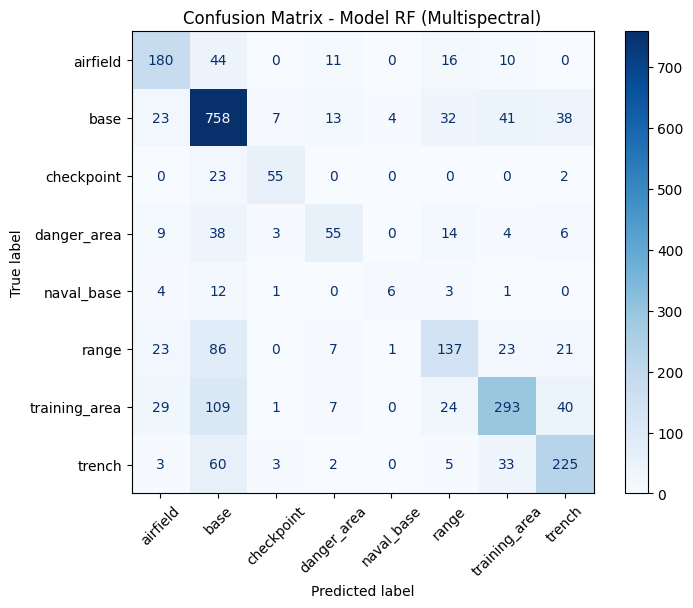

In [11]:
# Predicted value (class index)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Model RF (Multispectral)")
plt.show()

FeatureCollection size: 160
Region coordinates: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[39.7647773, 47.09798149999998], [39.8182243, 47.09798149999998], [39.8182243, 47.13122810000002], [39.7647773, 47.13122810000002], [39.7647773, 47.09798149999998]]]}
FeatureCollection size: 160
Region coordinates: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[125.93786950000002, 38.893511799999985], [125.9422413, 38.893511799999985], [125.9422413, 38.89778370000002], [125.93786950000002, 38.89778370000002], [125.93786950000002, 38.893511799999985]]]}
FeatureCollection size: 160
Region coordinates: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[134.1488685, 35.11732989999999], [134.1490782, 35.11732989999999], [134.1490782, 35.117591100000034], [134.1488685, 35.117591100000034], [134.1488685, 35.11732989999999]]]}
FeatureCollection size: 160
Region coordinates: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[36.3121532, 51.70789939999999], [36.3205486000

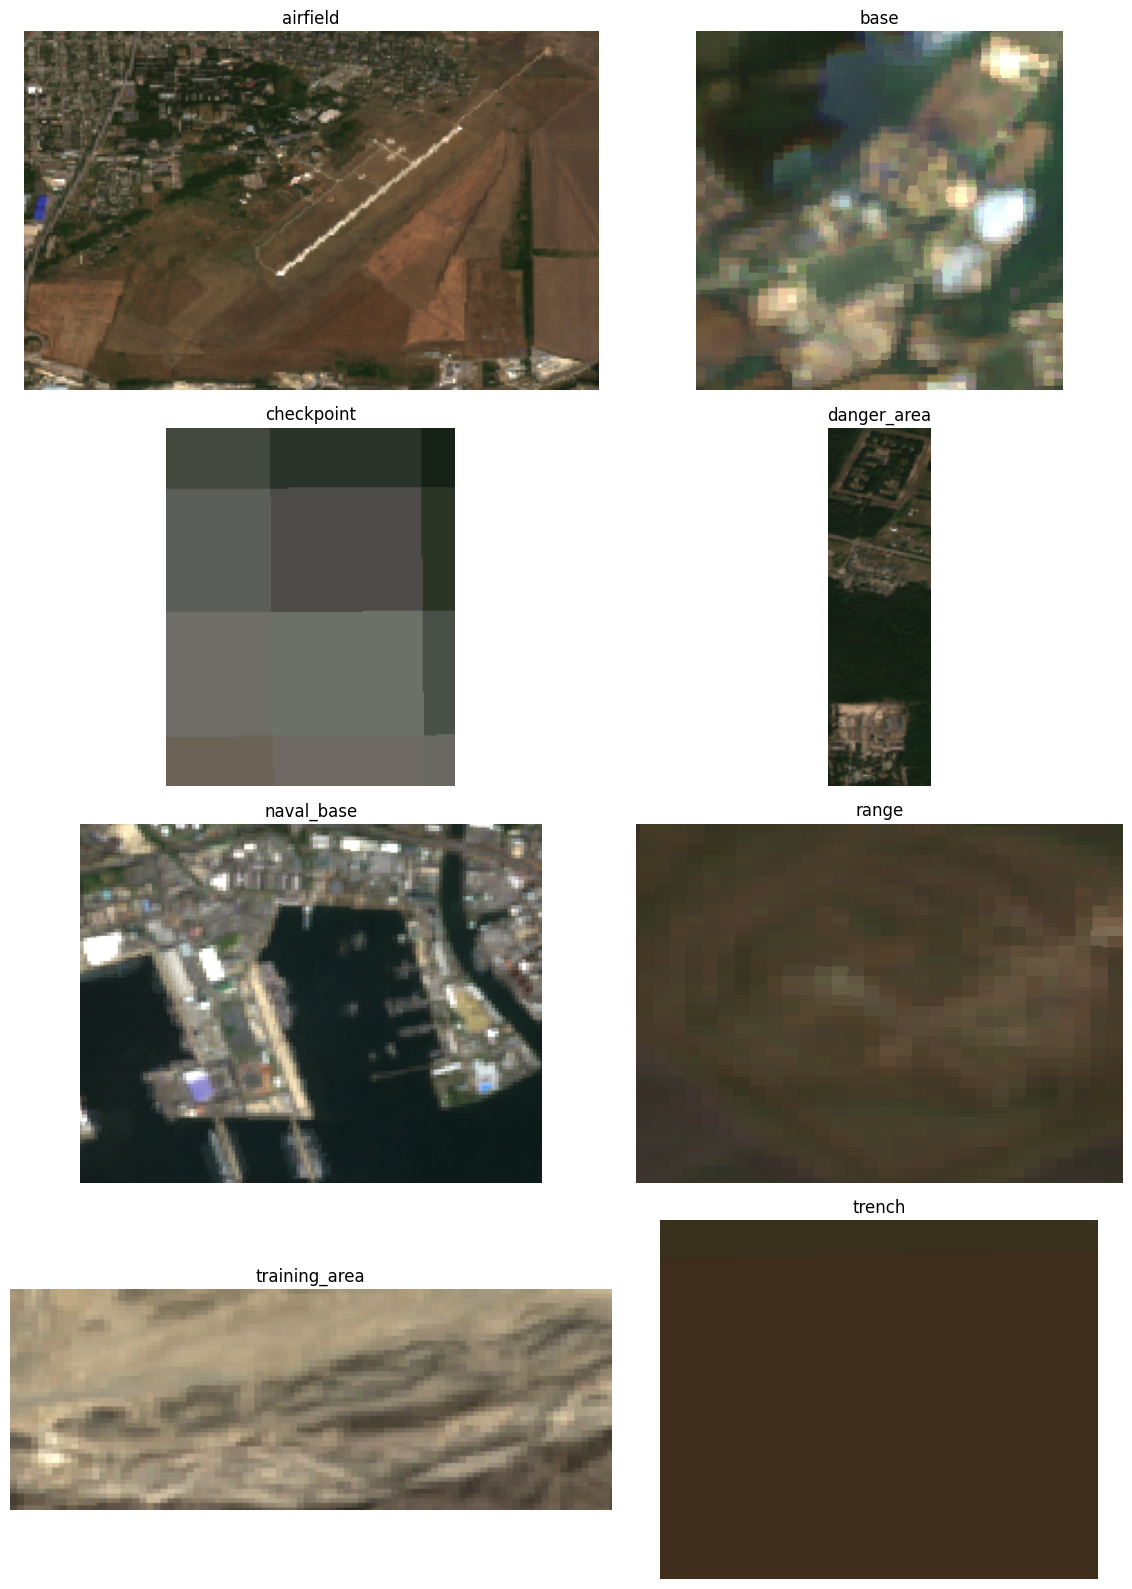

In [12]:
# GeoPandas → GEE FeatureCollection

# Sample 20 samples from each class
sampled_list = []

for m_type in class_names:
    m_type_df = final[final['military'] == m_type]
    sampled = m_type_df.sample(n=min(20, len(m_type_df)), random_state=44)
    sampled_list.append(sampled)

sampled_final = pd.concat(sampled_list)


features = []
for _, row in sampled_final.iterrows():
    try:
        coords = row.geometry.__geo_interface__['coordinates']
        if row.geometry.geom_type == 'Polygon':
            geom = ee.Geometry.Polygon(coords)
        elif row.geometry.geom_type == 'MultiPolygon':
            geom = ee.Geometry.MultiPolygon(coords)
        else:
            continue
        
        properties = row.drop('geometry').to_dict()
        clean_props = {k: (0 if pd.isna(v) else v) for k, v in properties.items()}
        features.append(ee.Feature(geom, clean_props))
    except Exception as e:
        print(f"⚠️ Error: {e}")
        continue

fc = ee.FeatureCollection(features)
s2_org_f = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-07-01', '2020-10-31')
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .filterBounds(fc)
    .median()
)

# List for visualization
images = []
labels = []

for m_type in class_names:
    filtered = fc.filter(ee.Filter.eq('military', m_type))
    region = filtered.first().geometry().bounds()
    # Check FeatureCollection size
    print("FeatureCollection size:", fc.size().getInfo())

    # Check Region
    print("Region coordinates:", region.getInfo())
    
    try:
        url = s2_org_f.getThumbURL({
            'min': 0,
            'max': 3000,
            'dimensions': 256,
            'region': region,
            'format': 'png',
            'bands': ['B4', 'B3', 'B2']  # RGB order
        })
    
        img = np.array(Image.open(urllib.request.urlopen(url)))

        

        images.append(img)
        labels.append(m_type)

    except Exception as e:
        print(f"{m_type} - Error: {e}")
        continue

# Visualize in 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(12, 16))
axs = axs.flatten()

for i, (img, label) in enumerate(zip(images, labels)):
    axs[i].imshow(img)
    axs[i].set_title(label)
    axs[i].axis('off')

# Hide empty subplots
for j in range(i + 1, 8):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

In [13]:
def compute_labeling_error_per_class(y_true, y_pred, class_names):
    error_stats = []

    for i, class_name in enumerate(class_names):
        total = np.sum(y_true == i)
        errors = np.sum((y_true == i) & (y_pred != i))
        error_rate = (errors / total) * 100 if total > 0 else 0

        error_stats.append({
            "Class": class_name,
            "Total Samples": int(total),
            "Misclassified": int(errors),
            "Error Rate (%)": round(error_rate, 2)
        })

    df = pd.DataFrame(error_stats)
    return df.sort_values("Error Rate (%)", ascending=False).reset_index(drop=True)

label_error_df = compute_labeling_error_per_class(y_true, y_pred_rf, class_names)
print(label_error_df)

           Class  Total Samples  Misclassified  Error Rate (%)
0     naval_base             27             21           77.78
1    danger_area            129             74           57.36
2          range            298            161           54.03
3  training_area            503            210           41.75
4         trench            331            106           32.02
5     checkpoint             80             25           31.25
6       airfield            261             81           31.03
7           base            916            158           17.25


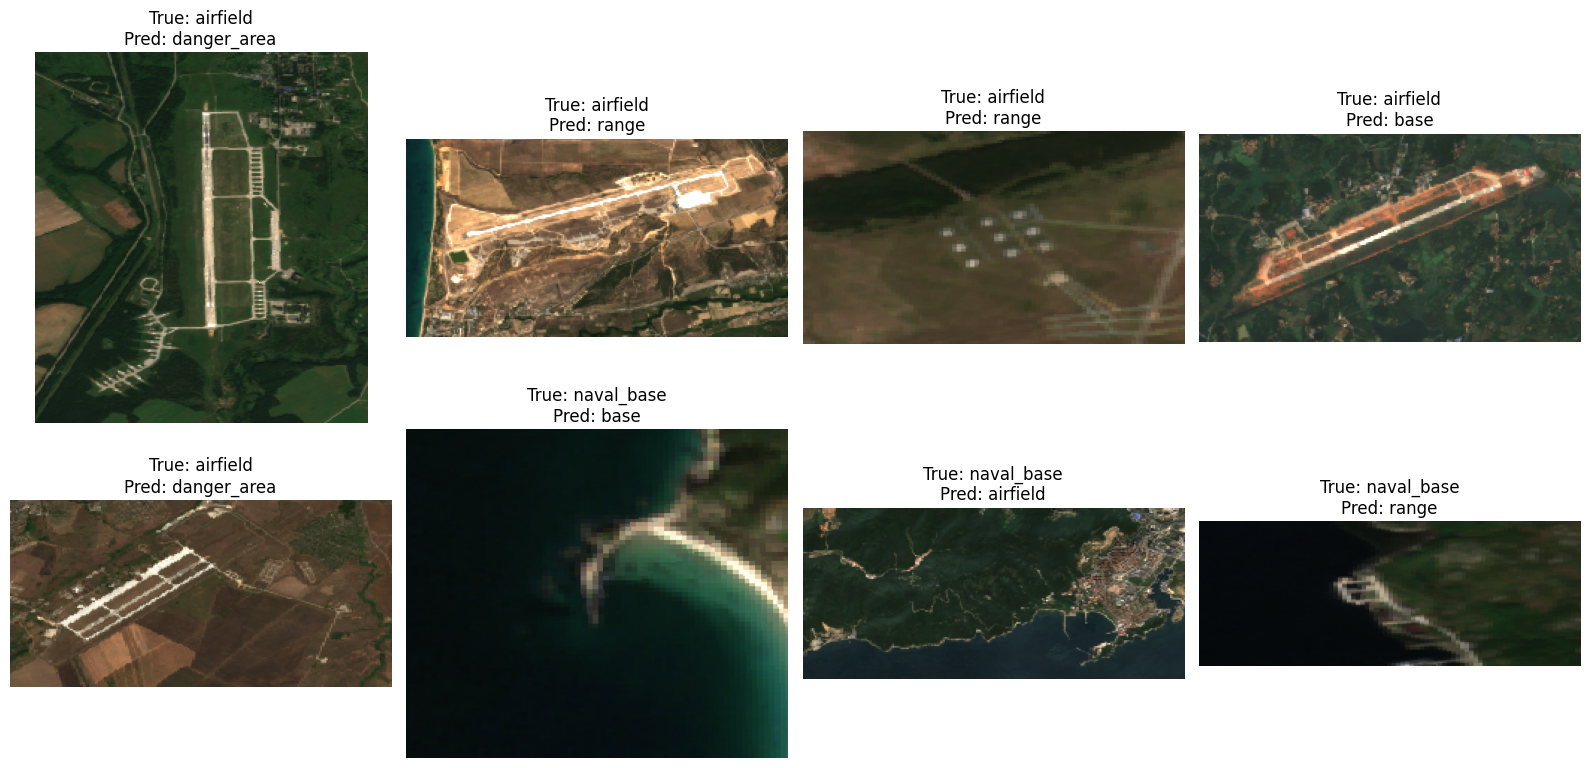

In [14]:
# Original GeoDataFrame based on the indices of the test set
final_test = final.loc[X_test.index].copy()
final_test["true_label"] = le.inverse_transform(y_test)
final_test["pred_label"] = le.inverse_transform(y_pred_rf)

# Misclassified samples (airfield, naval_base)
target_classes = ["airfield", "naval_base"]

misclassified = final_test[final_test["true_label"] != final_test["pred_label"]]
filtered = misclassified[misclassified["true_label"].isin(target_classes)]

# Extract the unique values of the 'true_label' attribute
sampled = filtered.sample(n=min(8, len(filtered)), random_state=42).reset_index(drop=True)

# 4. Create GEE FeatureCollection
features = []
for _, row in sampled.iterrows():
    try:
        coords = row.geometry.__geo_interface__["coordinates"]
        if row.geometry.geom_type == "Polygon":
            geom = ee.Geometry.Polygon(coords)
        elif row.geometry.geom_type == "MultiPolygon":
            geom = ee.Geometry.MultiPolygon(coords)
        else:
            continue

        props = {
            "true_label": row["true_label"],
            "pred_label": row["pred_label"]
        }
        features.append(ee.Feature(geom, props))
    except Exception as e:
        print(f"⚠️ Error: {e}")
        continue

fc = ee.FeatureCollection(features)

# Import Sentinel-2 Image
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2020-07-01", "2020-10-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .filterBounds(fc)
    .median()
)

# Visualize the images
images, titles = [], []

for f in features:
    try:
        geom = f.geometry()
        region = geom.buffer(300).bounds()

        visualized = s2.visualize(min=0, max=3000, bands=["B4", "B3", "B2"])

        url = visualized.getThumbURL({
            "dimensions": 256,
            "region": region,
            "format": "png"
        })

        img = np.array(Image.open(urllib.request.urlopen(url)))
        if img.mean() > 240:
            continue

        images.append(img)
        titles.append(f"True: {f.get('true_label').getInfo()}\nPred: {f.get('pred_label').getInfo()}")

    except Exception as e:
        print("❌ Image failed:", e)
        continue

# Visualize in 4x2 grid
cols, rows = 4, 2
fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axs = axs.flatten()

for i, (img, title) in enumerate(zip(images, titles)):
    axs[i].imshow(img)
    axs[i].set_title(title)
    axs[i].axis("off")

for j in range(i + 1, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

The following chunk is for prediction of missing category values, but is not executed since this application focuses on model performance.

In [15]:
# For prediction missing classification (later)
# final.loc[final['military'].isnull(), 'military'] = predicted_values

### 4. Result of Training using Clay Model

Model 2 uses pre-calculated embedding called [Clay Foundation Model](https://clay-foundation.github.io/model/index.html). According to their tutorial, "Clay’s model takes satellite imagery, along with information about location and time, as an input, and outputs embeddings, which are mathematical representations of a given area at a certain time on Earth’s surface. It uses a Vision Transformer architecture adapted to understand geospatial and temporal relations on Earth Observation data. The model is trained via Self-supervised learning (SSL) using a Masked Autoencoder (MAE) method." 

Clay model has strengths as follows:

- Generate semantic embeddings for any location and time.

- Fine-tune the model for downstream tasks such as classification, regression, and generative tasks

- Use the model as a backbone for other models.


#### 4.1 Clay MAE model

##### 4.1.1 Load Data (completed)

The same dataset (`final` for entire dataset, `train_df` for validation) as Model 1 were used in Model 2.

##### 4.1.2 Extract sampling points from Polygon for each row of train_df (functions defined, failed to run)

The functions that sample points at regular intervals within the Polygon and extract embeddings from them were defined as the following chunks, but failed to run.

In [ ]:
from shapely.geometry import Point
import random

def sample_points_from_polygon(polygon, min_points=64, max_spacing=0.001, min_spacing=0.0001):
    """
    Function of sampling points from polygon
    
    Args:
        polygon: Shapely polygon object
        min_points: minimum points to sample
        max_spacing: maximum grid space (unit: latitude/longitude)
        min_spacing: minimum grid space (unit: latitude/longitude)
    
    Returns:
        List of sampled points
    """

    spacing = max_spacing

    while spacing >= min_spacing:
        minx, miny, maxx, maxy = polygon.bounds

        x_offset = random.uniform(0, spacing/2)
        y_offset = random.uniform(0, spacing/2)

        lons = np.arange(minx+x_offset, maxx, spacing)
        lats = np.arange(miny+y_offset, maxy, spacing)

        points = [Point(lon, lat) for lat in lats for lon in lons if polygon.contains(Point(lon, lat))]

        print(f"Spacing: {spacing}, Points found: {len(points)}")

        if len(points) >= min_points:
            return points[:min_points]
        spacing = spacing / 2

    if len(points) >0:
        print(f"Warning: Only {len(points)} points found, duplicating to reach {min_points}")
        return [points[i % len(points)] for i in range(min_points)]
    else:
        raise ValueError(f"No valid points found in polygon: only {len(points)} points found")

In [ ]:
def create_patch(polygon, get_s2_patch, required_patches=64, max_attempts=128):
    """
    Function to create patch from polygon
    
    Args:
        polygon: Shapely polygon object
        get_s2_patch: function to get s2 image using coordinates
        required_patches: number of patches required
        max_attempts: maximum attempts to sample points
    
    Returns:
        Merged patch of shape (12, 16, 16)
    """
    try:
        points = sample_points_from_polygon(polygon, min_points=max_attempts)
    except ValueError as e:
        print(f"Error sampling points: {e}")
        centroid = polygon.centroid
        points = [centroid] * max_attempts
    
    patches = []
    attempt_count = 0

    for pt in points:
        if len(patches) >= required_patches:
            break
            
        if attempt_count >= max_attempts:
            break
            
        attempt_count += 1

        try:
            patch = get_s2_patch(pt.y, pt.x)  # (12, 2, 2)
            if patch.shape == (12, 2, 2): 
                patches.append(patch)
        except Exception as e:
            print(f"Patch error at {pt.x}, {pt.y}: {e}")
            continue

    if len(patches) < required_patches:
        if len(patches) > 0:
            print(f"Got only {len(patches)} patches, duplicating to reach {required_patches}")
            while len(patches) < required_patches:
                idx = random.randint(0, len(patches) - 1)
                patches.append(patches[idx])
        else:
            raise ValueError("Not enough valid patches")
    
    stacked = torch.stack(patches[:required_patches])  # (64, 12, 2, 2)
    merged = stacked.reshape(8, 8, 12, 2, 2).permute(2, 0, 3, 1, 4).reshape(12, 16, 16)
    return merged

In [ ]:
def extract_embeddings(df, get_s2_patch, model, save_dir="embeddings"):
    """
    Function to extract embeddings from each polygon in dataframe
    
    Args:
        df: dataframe (column of geometry, lat, lon, military etc)
        get_s2_patch: function to get s2 image using coordinates
        model: Clay model
        save_dir: embedding save directory
    
    Returns:
        array of embeddings, labels, valid_indices
    """
    os.makedirs(save_dir, exist_ok=True)

    embeddings = []
    labels = []
    valid_indices = []

    # Create a directory to save the patches from train_df and get embeddings 
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting embeddings"):
        try:
            patch = create_patch(row.geometry, get_s2_patch)
            datacube = {
                "pixels": patch.unsqueeze(0),
                "time": torch.tensor([[28.0, 13.0]]),
                "latlon": torch.tensor([[row["lat"], row["lon"]]]),
                "gsd": torch.tensor(10.0),
                "platform": ["sentinel-2"],
                "date": ["2020-07-15"]
            }

            with torch.no_grad():
                output = model(datacube)

            emb = output.cpu().numpy().squeeze()

            embeddings.append(emb)
            labels.append(row["military"])
            valid_indices.append(idx)
        except Exception as e:
            print(f"❌ Error at index {idx}: {e}")
        
    print(f"Successfully processed {len(embeddings)}/{len(df)} entries")
    
    if len(embeddings) == 0:
        raise ValueError("No valid embeddings were extracted")
    
    # 결과 저장
    embeddings_array = np.array(embeddings)
    labels_array = np.array(labels)
    valid_indices_array = np.array(valid_indices)
    
    np.save(f"{save_dir}/embeddings.npy", embeddings_array)
    np.save(f"{save_dir}/labels.npy", labels_array)
    np.save(f"{save_dir}/valid_indices.npy", valid_indices_array)
    
    return embeddings_array, labels_array, valid_indices_array

##### 4.1.3 Load Clay MAE Model (completed)

The function to load Clay Masked Autoencoder (MAE) Model was defined as the following code chunk.

In [82]:
import importlib
sys.path.append('./model')
import src.model
importlib.reload(src.model) 
from src.model import clay_mae_base

metadata = {
    "sentinel-2": {
        "gsd": 10,
        "bands": {
            "wavelength": {
                "B1": 443, "B2": 490, "B3": 560, "B4": 665,
                "B5": 705, "B6": 740, "B7": 783, "B8": 842,
                "B8A": 865, "B9": 945, "B11": 1610, "B12": 2190,
            }
        },
        "rgb_indices": [3, 2, 1],  # B4(R), B3(G), B2(B)
    }
}  # 이건 Clay 모델이 Sentinel-2 위성 데이터를 해석할 수 있게 도와주는 메타데이터야.

model = clay_mae_base(
    mask_ratio=0.0,
    patch_size=16,
    norm_pix_loss=False,
    shuffle=False,
    metadata=metadata,
    teacher="resnet18",
    dolls=[],
    doll_weights=[],
)
model.eval()

ClayMAE(
  (teacher): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act1): ReLU(inplace=True)
        (aa): Identity()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act2): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

#### 4.2 Classifier Training

In [80]:
def train_rf_model(embeddings, labels):
    """
    임베딩으로 랜덤 포레스트 모델 학습
    
    Args:
        embeddings: 특징 임베딩 배열
        labels: 라벨 배열
    
    Returns:
        학습된 모델과 평가 메트릭
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
    
    # 훈련/테스트 분할
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.3, random_state=42, stratify=labels
    )
    
    # 모델 학습
    rf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=None, 
        min_samples_split=2, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    )
    
    rf.fit(X_train, y_train)
    
    # 모델 평가
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(conf_matrix)
    
    return rf, (X_test, y_test, y_pred)

In [ ]:
 # 임베딩 추출
embeddings, labels, valid_indices = extract_embeddings(train_df, get_s2_patch, model)

# 모델 학습
rf_model, eval_results = train_rf_model(embeddings, labels)

# 모델 저장
import joblib
joblib.dump(rf_model, "rf_classifier_clay.joblib")
print("Model saved as rf_classifier_clay.joblib")

In [ ]:
#✅ 6. test_df에 대해 같은 방식으로 임베딩 추출 후 분류
# predictions = []
# for _, row in test_df.iterrows():
#     patch = create_patch(row.geometry, get_s2_patch)
#     datacube = ...
#     with torch.no_grad():
#         emb = model(datacube).cpu().numpy().squeeze()
#     pred = clf.predict([emb])
#     predictions.append(pred[0])

### 5. Conclusion and Discussion

Model 1 achieved an overall accuracy of 67%, with the following limitation identified.

1. There was a limitation in **defining classification criteria of military land use**. 15 class names produced by users were refined and integrated into 8 classes. However, **they originally have limitations in exclusivity, and it still exists after integration.** Eight classes were not referred from the specific country's military regulation, and even though they were, matching them with class names produced by users is a tricky part. Also, in remote sensing-based classification models, it is advisable to simplify the number of classes as much as possible. However, due to the diverse nature and operational distinctions of military installations, it was not feasible to define fewer than eight classes in this application. To minimize the number of classes, facilities such as spaceport, launchpad, nuclear explosion site, rocket engine test site, nuclear test range were grouped into 'range', a class with general ranges. Still, it is actually **skeptical that those criteria will get a broad consensus.**

    - Moreover, there was a class imbalance in the number of samples per category because of the category **base**. For example, general bases are far more numerous than naval bases or airfields, which appear less frequently. Separately from this, all military bases are "bases" in the grand scheme, **which may represents they do not have sub-categories.** In such an imbalanced setting, even objects that are visually obvious airfields could be misclassified as general bases even they did not mean to. To minimize such misclassifications, we may think of **removing "base" and changing it to NULL.**

2. **Non-military samples were not included in training.** To increase the number of known-class samples, the model utilized 4,049 labeled data from neighboring countries, beyond 231 labeled data from nK. However, the absence of true negative samples–objects that are definitively not military—limits the model’s performance in reducing false positives. If future models include non-military training data, it could be used with improved performance as well as generalizability.

3. Model 1 could **incorporate other valuable datasets such as 10-meter resolution DEMs or radar imagery**, which could have significantly enhanced its performance to detect and differentiate land use characteristics in a more multidimensional way.

Although Model 2 was not fully trained, it had the following limitations.

1. It was a challenge to make a strategy to sample within numerous geographically scattered polygons and assemble patches suitable for the Clay Foundation model. This step is widely acknowledged as the most technically challenging part of using Clay-based MAE models and deserves deeper methodological attention in future research.

2. Beyond its potential for computational efficiency compared to Model 1, the advantages of Model 2 in the context of this application were not clearly understood. We could have a more substantial justification linking the model’s performance to the goals of the application.

If this application succeeds, the potential user will be the non-intelligence users in the Republic of Korea government, considering the deployment of military bases while establishing urban plans in nK region in the event of future unification. Please note that this application is not intended for military purposes.


### 6. Reference

Ahn, D., Yang, J., Cha, M. et al. A human-machine collaborative approach measures economic development using satellite imagery. Nat Commun 14, 6811 (2023). https://doi.org/10.1038/s41467-023-42122-8

Dr. Shawn Barrett's LinkedIn https://www.linkedin.com/posts/samuel-barrett-b86b85171_yesterday-i-shared-a-quick-demo-activity-7313195715990577152-AyHw

https://clay-foundation.github.io/model/index.html